In [1]:
!apt-get update -qq
!apt-get install -y ncbi-blast+ > /dev/null

!blastp -version
!makeblastdb -version

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
blastp: 2.12.0+
 Package: blast 2.12.0, build Mar  8 2022 16:19:08
makeblastdb: 2.12.0+
 Package: blast 2.12.0, build Mar  8 2022 16:19:08


In [2]:
!pip install dgeb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 28.2 MB/s eta 0:00:00


In [3]:
!pip install pytrec_eval -q

  Preparing metadata (setup.py) ... done


In [4]:
from dgeb.tasks import ArchRetrieval, EukRetrieval
from collections import defaultdict
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pytrec_eval

KS = [5, 10, 50]


def load_dgeb_task(task_class, task_name):
    print(f"Loading {task_name} ...")

    task = task_class()
    meta = task.metadata

    data_ds = meta.datasets[0].load()
    qrels_ds = meta.datasets[1].load()

    corpus = {row["Entry"]: row["Sequence"] for row in data_ds["train"]}
    queries = {row["Entry"]: row["Sequence"] for row in data_ds["test"]}

    qrels = defaultdict(set)

    splits = list(qrels_ds.values()) if hasattr(qrels_ds, "values") else [qrels_ds]

    for split in splits:
        for row in split:
            qid = str(row["query_id"])
            cid = str(row["corpus_id"])

            if float(row["fuzz_ratio"]) > 0:
                qrels[qid].add(cid)

    print(f"  Corpus  : {len(corpus):,}")
    print(f"  Queries : {len(queries):,}")
    print(f"  Queries with ≥1 relevant doc: {len(qrels):,}")
    print(f"  Query/qrel overlap: {len(set(queries.keys()) & set(qrels.keys())):,}")

    return queries, corpus, dict(qrels)

arch_queries, arch_corpus, arch_qrels = load_dgeb_task(ArchRetrieval, "Arch Retrieval")
euk_queries, euk_corpus, euk_qrels = load_dgeb_task(EukRetrieval, "Euk Retrieval")

Loading Arch Retrieval ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/452 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/832k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/311 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/352 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/196k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29377 [00:00<?, ? examples/s]

  Corpus  : 3,202
  Queries : 311
  Queries with ≥1 relevant doc: 311
  Query/qrel overlap: 311


In [5]:
BLAST_DIR = "/content/blast_method1"
os.makedirs(BLAST_DIR, exist_ok=True)

def write_fasta(seq_dict, output_path):
    with open(output_path, "w") as f:
        for protein_id, seq in seq_dict.items():
            seq = str(seq).replace("*", "").replace(" ", "").replace("\n", "")
            f.write(f">{protein_id}\n")
            for i in range(0, len(seq), 80):
                f.write(seq[i:i+80] + "\n")

arch_query_fasta = os.path.join(BLAST_DIR, "arch_queries.fasta")
arch_corpus_fasta = os.path.join(BLAST_DIR, "arch_bacterial_corpus.fasta")

euk_query_fasta = os.path.join(BLAST_DIR, "euk_queries.fasta")
euk_corpus_fasta = os.path.join(BLAST_DIR, "euk_bacterial_corpus.fasta")

write_fasta(arch_queries, arch_query_fasta)
write_fasta(arch_corpus, arch_corpus_fasta)

write_fasta(euk_queries, euk_query_fasta)
write_fasta(euk_corpus, euk_corpus_fasta)

print("FASTA files written.")

FASTA files written.


In [6]:
print("FASTA files written.")
print("Arch queries:", len(arch_queries))
print("Arch corpus:", len(arch_corpus))
print("Euk queries:", len(euk_queries))
print("Euk corpus:", len(euk_corpus))

FASTA files written.
Arch queries: 2343
Arch corpus: 9229
Euk queries: 311
Euk corpus: 3202


In [7]:
arch_db = os.path.join(BLAST_DIR, "arch_bacterial_db")
euk_db = os.path.join(BLAST_DIR, "euk_bacterial_db")

!makeblastdb -in {arch_corpus_fasta} -dbtype prot -out {arch_db}
!makeblastdb -in {euk_corpus_fasta} -dbtype prot -out {euk_db}



Building a new DB, current time: 05/07/2026 03:39:40
New DB name:   /content/blast_method1/arch_bacterial_db
New DB title:  /content/blast_method1/arch_bacterial_corpus.fasta
Sequence type: Protein
Keep MBits: T
Maximum file size: 1000000000B
Adding sequences from FASTA; added 9229 sequences in 0.262584 seconds.




Building a new DB, current time: 05/07/2026 03:39:40
New DB name:   /content/blast_method1/euk_bacterial_db
New DB title:  /content/blast_method1/euk_bacterial_corpus.fasta
Sequence type: Protein
Keep MBits: T
Maximum file size: 1000000000B
Adding sequences from FASTA; added 3202 sequences in 0.104578 seconds.




In [8]:
arch_blast_tsv = os.path.join(BLAST_DIR, "blast_arch.tsv")
euk_blast_tsv = os.path.join(BLAST_DIR, "blast_euk.tsv")

outfmt = "6 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore"

In [9]:
!blastp \
-query {arch_query_fasta} \
-db {arch_db} \
-out {arch_blast_tsv} \
-outfmt "{outfmt}" \
-evalue 10 \
-max_target_seqs 100 \
-num_threads 2

print("Arch BLASTP complete.")

Arch BLASTP complete.


In [10]:
!blastp \
-query {euk_query_fasta} \
-db {euk_db} \
-out {euk_blast_tsv} \
-outfmt "{outfmt}" \
-evalue 10 \
-max_target_seqs 100 \
-num_threads 2

print("Euk BLASTP complete.")

Euk BLASTP complete.


In [11]:
BLAST_COLS = [
    "query_id", "corpus_id", "pident", "length", "mismatch", "gapopen",
    "qstart", "qend", "sstart", "send", "evalue", "bitscore"
]

def parse_blast(path, task_name):
    df = pd.read_csv(path, sep="\t", names=BLAST_COLS)
    df["task"] = task_name

    df = df.sort_values(
        ["query_id", "evalue", "bitscore"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

    return df

arch_blast_df = parse_blast(arch_blast_tsv, "arch")
euk_blast_df = parse_blast(euk_blast_tsv, "euk")

display(arch_blast_df.head())
display(euk_blast_df.head())

,query_id,corpus_id,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,task
0,A0A0S1X9S7,B1YI19,24.554,224,136,10,87,307,99,292,0.002,37.7,arch
1,A0A0S1X9S7,C5D3E0,20.500,200,128,4,10,201,15,191,0.018,35.0,arch
2,A0A0S1X9S7,Q8KCK9,23.977,171,104,6,128,284,117,275,0.061,33.1,arch
3,A0A0S1X9S7,A5N6A8,30.000,100,61,5,9,100,14,112,1.400,28.9,arch
4,A0A0S1X9S7,B0S101,30.120,83,36,3,297,378,660,721,1.600,28.9,arch


,query_id,corpus_id,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore,task
0,A0A0B5L585,Q7UJL3,36.381,514,285,10,37,547,56,530,2.800000e-93,292.0,euk
1,A0A0B5L585,Q8G3N6,38.095,483,257,9,37,508,54,505,3.490000e-92,289.0,euk
2,A0A0B5L585,P49058,37.624,303,165,9,246,540,116,402,6.470000e-48,168.0,euk
3,A0A0B5L585,P49058,42.169,83,48,0,36,118,9,91,1.030000e-14,72.8,euk
4,A0A0B5L585,B9K819,20.769,130,80,3,274,382,18,145,2.900000e-01,30.0,euk


In [12]:
df_blast = pd.concat(
    [
        arch_blast_df[["task", "query_id", "corpus_id", "pident", "evalue", "bitscore"]],
        euk_blast_df[["task", "query_id", "corpus_id", "pident", "evalue", "bitscore"]]
    ],
    ignore_index=True
)

blast_pident_path = os.path.join("/content/blast_method1/", "blast_pident.csv")
df_blast.to_csv(blast_pident_path, index=False)

print("Saved:", blast_pident_path)
display(df_blast.head())

Saved: /content/blast_method1/blast_pident.csv


,task,query_id,corpus_id,pident,evalue,bitscore
0,arch,A0A0S1X9S7,B1YI19,24.554,0.002,37.7
1,arch,A0A0S1X9S7,C5D3E0,20.500,0.018,35.0
2,arch,A0A0S1X9S7,Q8KCK9,23.977,0.061,33.1
3,arch,A0A0S1X9S7,A5N6A8,30.000,1.400,28.9
4,arch,A0A0S1X9S7,B0S101,30.120,1.600,28.9


In [13]:
def blast_to_retrieved_list(blast_df, query_ids, max_k):
    topk = (
        blast_df
        .groupby("query_id")["corpus_id"]
        .apply(lambda x: list(dict.fromkeys(x))[:max_k])
        .to_dict()
    )

    return [topk.get(str(qid), []) for qid in query_ids]

arch_blast_retrieved = blast_to_retrieved_list(
    arch_blast_df,
    list(arch_queries.keys()),
    max_k=max(KS)
)

euk_blast_retrieved = blast_to_retrieved_list(
    euk_blast_df,
    list(euk_queries.keys()),
    max_k=max(KS)
)


In [14]:
def qrels_to_pytrec(qrels):
    return {
        str(qid): {str(cid): 1 for cid in rel_docs}
        for qid, rel_docs in qrels.items()
    }

def retrieved_list_to_run(query_ids, retrieved_list):
    run = {}

    for qid, docs in zip(query_ids, retrieved_list):
        qid = str(qid)
        run[qid] = {}

        for rank, doc_id in enumerate(docs):
            run[qid][str(doc_id)] = float(len(docs) - rank)

    return run

def evaluate_retrieval_pytrec_flexible(query_ids, retrieved_list, qrels, ks=[5, 10, 50]):
    pytrec_qrels = qrels_to_pytrec(qrels)
    pytrec_run = retrieved_list_to_run(query_ids, retrieved_list)

    metric_set = set()
    for k in ks:
        metric_set.update({
            f"map_cut.{k}",
            f"ndcg_cut.{k}",
            f"P.{k}",
            f"recall.{k}"
        })

    evaluator = pytrec_eval.RelevanceEvaluator(pytrec_qrels, metric_set)
    scores = evaluator.evaluate(pytrec_run)

    valid_qids = [str(qid) for qid in query_ids if str(qid) in pytrec_qrels]

    results = {}

    for k in ks:
        results[f"MAP@{k}"] = np.mean([scores[qid][f"map_cut_{k}"] for qid in valid_qids])
        results[f"nDCG@{k}"] = np.mean([scores[qid][f"ndcg_cut_{k}"] for qid in valid_qids])
        results[f"Precision@{k}"] = np.mean([scores[qid][f"P_{k}"] for qid in valid_qids])
        results[f"Recall@{k}"] = np.mean([scores[qid][f"recall_{k}"] for qid in valid_qids])

        mrr_scores = []

        for i, qid in enumerate(query_ids):
            qid = str(qid)

            if qid not in pytrec_qrels:
                continue

            retrieved = retrieved_list[i]
            relevant_docs = set(pytrec_qrels[qid].keys())

            rr = 0.0

            for rank, doc_id in enumerate(retrieved[:k], start=1):
                if str(doc_id) in relevant_docs:
                    rr = 1.0 / rank
                    break

            mrr_scores.append(rr)

        results[f"MRR@{k}"] = np.mean(mrr_scores)

    results["n_queries"] = len(valid_qids)

    return results

In [15]:
def average_precision_at_k(retrieved: list, relevant: set, k: int = 5) -> float:
    """Compute Average Precision@k for a single query."""
    if not relevant:
        return 0.0
    hits, score = 0, 0.0
    for rank, doc_id in enumerate(retrieved[:k], start=1):
        if doc_id in relevant:
            hits += 1
            score += hits / rank
    return score / min(len(relevant), k)


def ndcg_at_k(retrieved: list, relevant: set, k: int = 5) -> float:
    """Compute nDCG@k for a single query (binary relevance)."""
    if not relevant:
        return 0.0
    dcg = sum(
        (1.0 if doc_id in relevant else 0.0) / np.log2(rank + 1)
        for rank, doc_id in enumerate(retrieved[:k], start=1)
    )
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / np.log2(rank + 1) for rank in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else 0.0


def recall_at_k(retrieved: list, relevant: set, k: int = 5) -> float:
    """Compute Recall@k for a single query."""
    if not relevant:
        return 0.0
    hits = sum(1 for doc_id in retrieved[:k] if doc_id in relevant)
    return hits / len(relevant)


def evaluate_retrieval(
    query_ids: list,
    all_retrieved: list,
    qrels: dict,
    k: int = 5,
) -> dict:
    """Compute MAP@k, nDCG@k, Recall@k across all queries.

    Queries without any relevant document are excluded from the average
    (consistent with DGEB evaluation).
    """
    maps, ndcgs, recalls = [], [], []
    for qid, retrieved in zip(query_ids, all_retrieved):
        relevant = qrels.get(qid, set())
        if not relevant:
            continue
        maps.append(average_precision_at_k(retrieved, relevant, k))
        ndcgs.append(ndcg_at_k(retrieved, relevant, k))
        recalls.append(recall_at_k(retrieved, relevant, k))

    return {
        f'MAP@{k}':    float(np.mean(maps))    if maps else 0.0,
        f'nDCG@{k}':   float(np.mean(ndcgs))   if ndcgs else 0.0,
        f'Recall@{k}': float(np.mean(recalls)) if recalls else 0.0,
        'n_queries':   len(maps),
    }

In [17]:
blast_arch_metrics = evaluate_retrieval_pytrec_flexible(
    query_ids=list(arch_queries.keys()),
    retrieved_list=arch_blast_retrieved,
    qrels=arch_qrels,
    ks=KS
)

blast_euk_metrics = evaluate_retrieval_pytrec_flexible(
    query_ids=list(euk_queries.keys()),
    retrieved_list=euk_blast_retrieved,
    qrels=euk_qrels,
    ks=KS
)

df_blast_results_pytrec_flexible = pd.DataFrame([
    {
        "Method": "BLASTP",
        "Task": "Arch Retrieval",
        **blast_arch_metrics
    },
    {
        "Method": "BLASTP",
        "Task": "Euk Retrieval",
        **blast_euk_metrics
    }
])

display(df_blast_results_pytrec_flexible)

,Method,Task,MAP@5,nDCG@5,Precision@5,Recall@5,MRR@5,MAP@10,nDCG@10,Precision@10,Recall@10,MRR@10,MAP@50,nDCG@50,Precision@50,Recall@50,MRR@50,n_queries
0,BLASTP,Arch Retrieval,0.298707,0.902394,0.816645,0.304879,0.930161,0.415861,0.887001,0.742894,0.425883,0.930884,0.697668,0.821627,0.422168,0.717506,0.931174,2343
1,BLASTP,Euk Retrieval,0.340344,0.887153,0.802572,0.343273,0.916774,0.457467,0.870323,0.705145,0.460890,0.916774,0.673605,0.789289,0.342251,0.678777,0.916774,311


In [19]:
CHECKPOINT_DIR = "/content/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [20]:
df_blast_results_pytrec_flexible.to_csv(
    "/content/checkpoints/blast_retrieval_metrics_k5_k10_k50.csv",
    index=False
)

In [21]:
def save_predictions(blast_df, query_ids, path):
    rows = []

    grouped = (
        blast_df
        .groupby("query_id")["corpus_id"]
        .apply(lambda x: list(dict.fromkeys(x))[:50])
        .to_dict()
    )

    for qid in query_ids:
        qid = str(qid)
        docs = grouped.get(qid, [])

        for rank, doc_id in enumerate(docs, start=1):
            rows.append({
                "query_id": qid,
                "corpus_id": str(doc_id),
                "rank": rank
            })

    df = pd.DataFrame(rows)
    df.to_csv(path, index=False)
    print("Saved:", path)

save_predictions(
    arch_blast_df,
    list(arch_queries.keys()),
    os.path.join(BLAST_DIR, "blast_top50_arch.csv")
)

save_predictions(
    euk_blast_df,
    list(euk_queries.keys()),
    os.path.join(BLAST_DIR, "blast_top50_euk.csv")
)

Saved: /content/blast_method1/blast_top50_arch.csv
Saved: /content/blast_method1/blast_top50_euk.csv


In [22]:
def bin_by_pident(pident: float) -> str:
    if pident >= 40:
        return ">40% (High)"
    if pident >= 20:
        return "20-40% (Medium)"
    return "<20% (Twilight)"


def twilight_zone_map(
    query_ids: list,
    retrieved_list: list,
    qrels: dict,
    df_blast_pident: pd.DataFrame,
    task_filter: str,
    k: int = 5,
) -> dict:
    task_blast = df_blast_pident[df_blast_pident["task"] == task_filter].copy()

    max_pident = (
        task_blast
        .groupby("query_id")["pident"]
        .max()
        .to_dict()
    )

    bin_aps = {
        ">40% (High)": [],
        "20-40% (Medium)": [],
        "<20% (Twilight)": []
    }

    for qid, retrieved in zip(query_ids, retrieved_list):
        qid = str(qid)
        relevant = qrels.get(qid, set())

        if not relevant:
            continue

        pident = max_pident.get(qid, 0.0)
        bin_label = bin_by_pident(pident)

        ap = average_precision_at_k(retrieved, relevant, k)
        bin_aps[bin_label].append(ap)

    return {
        bin_label: {
            "MAP@5": float(np.mean(aps)) if aps else np.nan,
            "n_queries": len(aps)
        }
        for bin_label, aps in bin_aps.items()
    }

,Method,Task,Bin,MAP@5,n_queries
1,BLASTP,Arch Retrieval,20-40% (Medium),0.847069,290
2,BLASTP,Arch Retrieval,<20% (Twilight),NaN,0
0,BLASTP,Arch Retrieval,>40% (High),0.893847,2053
4,BLASTP,Euk Retrieval,20-40% (Medium),0.788636,44
5,BLASTP,Euk Retrieval,<20% (Twilight),NaN,0
3,BLASTP,Euk Retrieval,>40% (High),0.889494,267


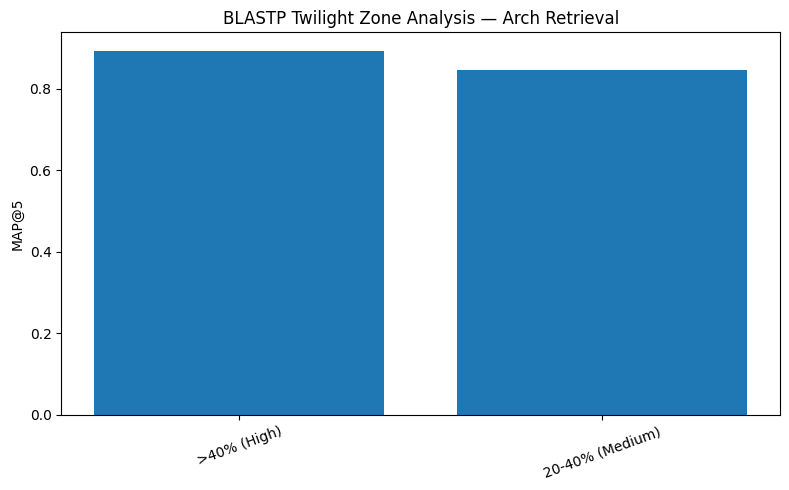

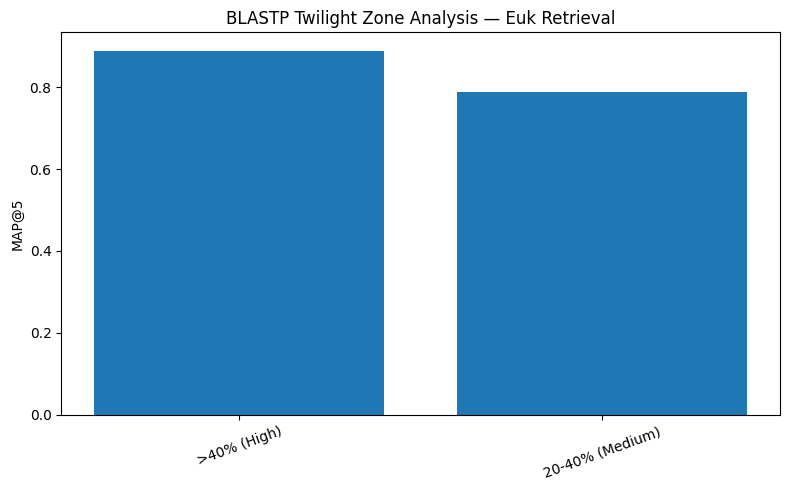

In [23]:
TZ_RESULTS = []

def add_tz_rows(method, task_label, task_key, query_ids, retrieved_list, qrels):
    tz = twilight_zone_map(
        query_ids=query_ids,
        retrieved_list=retrieved_list,
        qrels=qrels,
        df_blast_pident=df_blast,
        task_filter=task_key,
        k=5
    )

    for bin_label, vals in tz.items():
        TZ_RESULTS.append({
            "Method": method,
            "Task": task_label,
            "Bin": bin_label,
            "MAP@5": vals["MAP@5"],
            "n_queries": vals["n_queries"]
        })


add_tz_rows(
    "BLASTP",
    "Arch Retrieval",
    "arch",
    list(arch_queries.keys()),
    arch_blast_retrieved,
    arch_qrels
)

add_tz_rows(
    "BLASTP",
    "Euk Retrieval",
    "euk",
    list(euk_queries.keys()),
    euk_blast_retrieved,
    euk_qrels
)

if "df_best" in globals() and "RETRIEVAL_RESULTS" in globals():
    for task_key, task_label, query_ids, qrels in [
        ("arch", "Arch Retrieval", TASK_CONFIG["arch"]["query_ids"], arch_qrels),
        ("euk", "Euk Retrieval", TASK_CONFIG["euk"]["query_ids"], euk_qrels)
    ]:
        for size in ["35M", "150M", "650M"]:
            row = df_best[
                (df_best["Method"] == f"ESM2-{size}") &
                (df_best["Task"] == task_label)
            ]

            if row.empty:
                continue

            best_layer = row.iloc[0]["Layer"]
            retrieved = RETRIEVAL_RESULTS[(size, best_layer, task_key)]

            add_tz_rows(
                f"ESM2-{size}",
                task_label,
                task_key,
                query_ids,
                retrieved,
                qrels
            )

df_twilight_comparison = pd.DataFrame(TZ_RESULTS)

display(
    df_twilight_comparison.sort_values(["Task", "Bin", "Method"])
)

df_twilight_comparison.to_csv(
    os.path.join("/content/blast_method1/", "twilight_comparison_blast_esm2.csv"),
    index=False
)

for task in ["Arch Retrieval", "Euk Retrieval"]:
    plot_df = df_twilight_comparison[df_twilight_comparison["Task"] == task]

    plt.figure(figsize=(8, 5))
    plt.bar(plot_df["Bin"], plot_df["MAP@5"])
    plt.ylabel("MAP@5")
    plt.title(f"BLASTP Twilight Zone Analysis — {task}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

In [24]:
print(len(arch_queries), len(arch_corpus))
print(len(euk_queries), len(euk_corpus))

2343 9229
311 3202


In [26]:
df_twilight_comparison.to_csv(
    os.path.join(BLAST_DIR, "blast_twilight_results.csv"),
    index=False
)